In [59]:
from tensorflow.keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

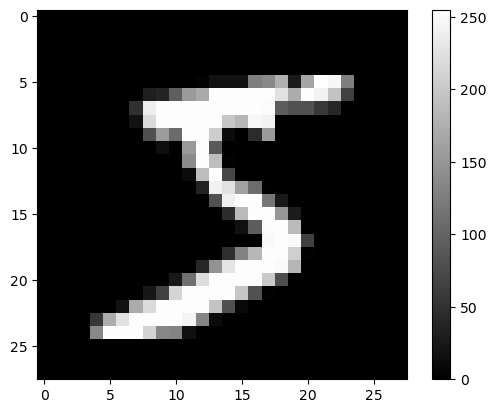

In [60]:
import matplotlib.pyplot as plt

plt.imshow(x_train[0], cmap='gray')
plt.colorbar()
plt.show()

In [63]:
type(x_train)

numpy.ndarray

In [78]:
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

# 1) Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2) Normalize pixel values to the range [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# 3) Define a simple model: Flatten + one hidden dense layer + output layer (10 classes)
model = models.Sequential([
    
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    
    # Hidden layer
    layers.Dense(100, activation="relu"),
    
    # Output layer (10 classes)
    layers.Dense(10, activation="softmax")
])

# 4) Compile the model
model.compile(
    optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 5) Train the model
model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

# 6) Evaluate the model on the test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step - accuracy: 0.4824 - loss: 1.7254 - val_accuracy: 0.8738 - val_loss: 0.6580
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - accuracy: 0.8454 - loss: 0.6552 - val_accuracy: 0.9007 - val_loss: 0.4366
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.8735 - loss: 0.4898 - val_accuracy: 0.9113 - val_loss: 0.3644
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 640us/step - accuracy: 0.8862 - loss: 0.4232 - val_accuracy: 0.9175 - val_loss: 0.3280
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - accuracy: 0.8932 - loss: 0.3884 - val_accuracy: 0.9215 - val_loss: 0.3053
Test accuracy: 0.9053999781608582


In [69]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [87]:
import numpy as np
from numpy.linalg import solve
from tensorflow.keras import layers, models
from strong_rank_revealing import strong_rrqr

def prune_1hidden_by_id_rrqr(model, x_unlabeled, keep_ratio=0.7, f=2.0, n_prune=5000):
    """
    For a model of the form:
        Flatten -> Dense(m, relu) -> Dense(10, softmax)

    Returns:
        pruned_model, I, T
    """
    # ------- Extract weights -------
    W1, b1 = model.layers[1].get_weights()   # (784, 100), (100,)
    W2, b2 = model.layers[2].get_weights()   # (100, 10), (10,)
    d, m = W1.shape
    c = W2.shape[1]

    # ------- Determine number of neurons to keep -------
    k = int(m * keep_ratio)
    k = max(1, min(k, m - 1))

    # ------- Prepare pruning data X ∈ R^{d×n} -------
    X = x_unlabeled[:n_prune].reshape(n_prune, -1).T  # (784, n)

    # ------- Absorb bias into W via augmentation -------
    W1_aug = np.vstack([W1, b1.reshape(1, -1)])        # (785, 100)
    X_aug  = np.vstack([X, np.ones((1, X.shape[1]))])  # (785, n)

    # ------- Compute activations Z = relu(W^T X) -------
    Z = np.maximum(W1_aug.T @ X_aug, 0.0)   # (m, n)

    # ------- Perform ID on Z^T: M = Z^T ∈ R^{n×m} -------
    M = Z.T

    # RRQR factorization: M @ Pi = Q @ R
    _, R, Pi = strong_rrqr(M, k, f=f)

    # Convert permutation matrix Pi to permutation index
    # I contains the first k representative columns (selected neurons)
    perm = np.argmax(Pi, axis=0)   # length m
    I = perm[:k]

    # Construct interpolation matrix:
    # T_hat = [I, R11^{-1} R12] (in permuted column order)
    R11 = R[:k, :k]
    R12 = R[:k, k:]
    T_hat = np.hstack([np.eye(k), solve(R11, R12)])   # (k, m)

    # Convert back to original column order:
    # T = T_hat @ Pi^T  (k × m)
    T = T_hat @ Pi.T

    # ------- Construct pruned parameters -------
    # First layer: select subset of neurons
    W1_hat = W1[:, I]      # (784, k)
    b1_hat = b1[I]         # (k,)

    # Second layer update: U_hat = T U
    W2_hat = T @ W2        # (k, 10)
    b2_hat = b2.copy()     # (10,)

    # ------- Build pruned model -------
    pruned = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(k, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    pruned.build((None, 28, 28))
    pruned.layers[1].set_weights([W1_hat, b1_hat])
    pruned.layers[2].set_weights([W2_hat, b2_hat])

    return pruned, I, T


# Use training data as unlabeled pruning data
pruned_model, I, T = prune_1hidden_by_id_rrqr(
    model,
    x_unlabeled=x_train,
    keep_ratio=0.7,
    f=2.0,
    n_prune=5000
)

pruned_model.compile(
    #optimizer="sgd",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Original test:")
print(model.evaluate(x_test, y_test, verbose=0))

print("Pruned test (no finetuning):")
print(pruned_model.evaluate(x_test, y_test, verbose=0))

Original test:
[0.34789904952049255, 0.9053999781608582]
Pruned test (no finetuning):
[0.3549744486808777, 0.9027000069618225]


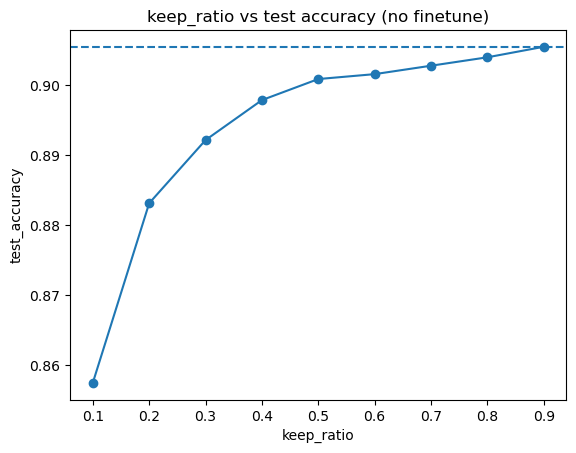

In [91]:
import matplotlib.pyplot as plt

# baseline accuracy
base_loss, base_acc = model.evaluate(x_test, y_test, verbose=0)

ratios = np.linspace(0.1, 0.9, 9)
accs = []

for r in ratios:
    pruned_model, I, T = prune_1hidden_by_id_rrqr(
        model,
        x_unlabeled=x_train,
        keep_ratio=float(r),
        f=2.0,
        n_prune=5000
    )

    pruned_model.compile(
        #optimizer="sgd",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    loss, acc = pruned_model.evaluate(x_test, y_test, verbose=0)
    accs.append(acc)

plt.figure()
plt.plot(ratios, accs, marker="o")
plt.axhline(base_acc, linestyle="--")
plt.xlabel("keep_ratio")
plt.ylabel("test_accuracy")
plt.title("keep_ratio vs test accuracy (no finetune)")
plt.show()